# Advanced Visualization - Leiden Clustering

## 1) Objective
In contrast to UMAP, Leiden is not just a visualization tool, it is an **actual clustering method** and therefore an unsupervised learning algorithm. Leiden creates a graph of the data set by exploring the neighbourhood of each data point and connects each data point to its $k$ nearest neighbours. By comparing how many neighbours each data point has in common with other data points, Leiden assigns these data points to communities, i.e. cluster or label.<br>
We can visualize the graph directly using the Python library ```networkx``` or map the labelled data into lower dimensions using UMAP.

## 2) Preparation

First, we import the standard libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Next, we need the library that performs the leiden clustering:

In [3]:
import leidenalg #pip install leidenalg

We also need the libraries for visualizing the graph (see ```Graph.ipynb```)

In [6]:
import igraph as ig #pip install igraph
import networkx as nx

and mapping the data into 2D or 3D via UMAP if we wish to do so:

In [5]:
import umap.umap_ as umap

We want to understand to some extent how Leiden works and therefore want to generate a graph using $k$ nearest neighbours which again requires loading a new library.

In [7]:
from sklearn.neighbors import NearestNeighbors

Next, we import the ```MinMaxScaler``` in order to normalize the data before we run Leiden.

In [8]:
from sklearn.preprocessing import MinMaxScaler

And finally, we call the digits dataset (see ```WalkThroughUMAP.ipynb```):

In [9]:
from sklearn.datasets import load_digits

<br>

## 3) Loading Data Sets

As in ```WalkThroughUMAP.ipynb```, let us plot the digits data set first using PCA.

In [10]:
from sklearn.decomposition import PCA

This set is easy to understand, because the labels are just the digits and we therefore can immediately tell, if the UMAP projection makes sense. For example the numbers *"1"* and *"8"* should be located in well separated cluster, whereas the numbers *"3"* and *"8"* can be easly mistaken when handwritten and therefore the cluster should exhibit some overlap.

In [11]:
digits = load_digits()

We extract the labels and values (X) and display the first entries

In [12]:
XDigits = digits.data
YDigits = digits.target

In [13]:
print(YDigits[:10])

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
print(XDigits[:5, :])

In [15]:
print(YDigits.shape, XDigits.shape)

(1797,) (1797, 64)


Each of the 1797 digits is encoded in a 64-dimensional feature vector. As it turns out, this feature vector is just the flattened gray scale image of the handwritten digit. Let's plot the first data point as an image... 

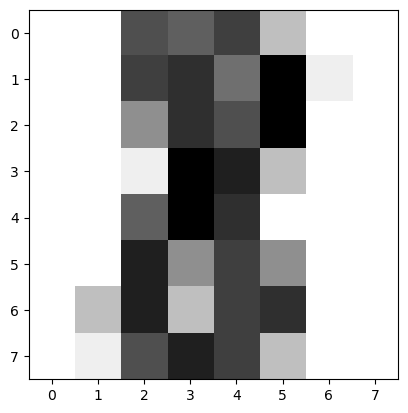

In [16]:
Number  = XDigits[40,:]
S       = int(len(Number)**0.5)
NumberR = Number.reshape((S, S))
plt.imshow(NumberR, cmap = 'gray_r')

...and repeat that with the first 400 entries:

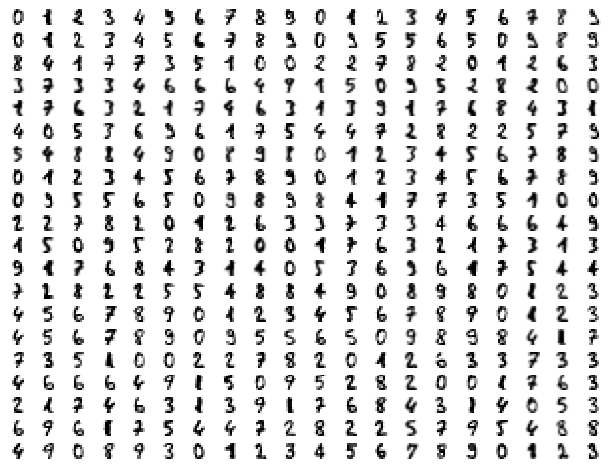

In [17]:
fig, ax_array = plt.subplots(20, 20)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    Number  = XDigits[i,:]
    NumberR = Number.reshape((S, S))
    ax.imshow(NumberR, cmap = 'gray_r')
plt.setp(axes, xticks = [], yticks = [], frame_on = False)
plt.tight_layout(h_pad = 0.5, w_pad = 0.01)

Let's scale the dataset and run PCA for ```n_components = 2``` and visualize the result.

In [18]:
MinMax   = MinMaxScaler()
XSDigits = MinMax.fit_transform(XDigits)

PCA:

In [19]:
out = PCA(n_components = 2).fit(XSDigits) 
eigenVec = out.components_
eigenVal = out.explained_variance_
eigenX   = out.transform(XSDigits)

Plot:

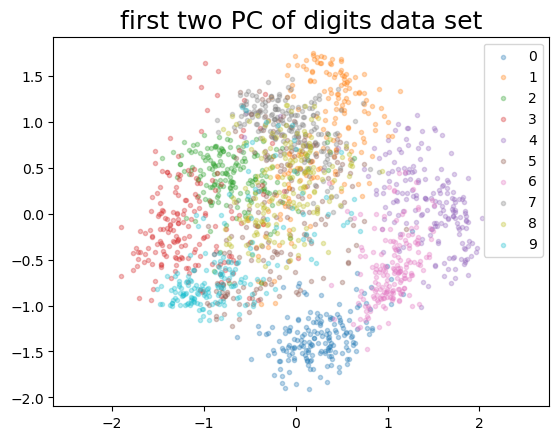

In [20]:
for i in range(np.max(YDigits)+1):
    idx = np.argwhere(YDigits == i)
    plt.scatter(eigenX[idx, 0], eigenX[idx, 1], marker = '.', alpha = 0.3, label = str(i))

plt.gca().set_aspect('equal', 'datalim')
plt.title('first two PC of digits data set', fontsize = 18)
plt.legend()
plt.show()

There is some clustering, but we plotted only the first two directions which contain only a part of the explained variance.

<br>

## 4) The Graph (no Leiden yet)

Let us now construct a graph of the dataset by just connecting the $k$ nearest neighbours of each data point and let's see what we get. We start with running $k$ nearest neighbours: 

In [22]:
k = 10  # number of neighbors
nbrs               = NearestNeighbors(n_neighbors = k).fit(XSDigits)
distances, indices = nbrs.kneighbors(XSDigits)

For each data point we get the $k$ distances to its $k$ neighbours which results in a $N \times k$ matrix if $N$ is the number of data points...

In [23]:
print(distances[:5])

[[0.         0.68552592 0.8047859  0.82914466 0.83594277 0.84188217
  0.85229366 0.96976782 0.97827974 0.99891345]
 [0.         0.91185231 1.2243479  1.22753423 1.24019768 1.33104622
  1.33865475 1.34593008 1.3531663  1.37748513]
 [0.         1.09027326 1.54807159 1.58644911 1.62175893 1.72212678
  1.74541014 1.76368103 1.77911728 1.78131154]
 [0.         0.8772293  0.95873069 1.20433157 1.24107143 1.26243812
  1.30616113 1.35589277 1.36645069 1.38110311]
 [0.         1.16557195 1.36177598 1.39471043 1.46523815 1.47173928
  1.49191427 1.53373523 1.65097846 1.66176447]]


 ...and the corresponding indicies of the data points.

In [24]:
print(indices[:5])

[[   0  877 1365 1541 1167 1029  464  957 1697  855]
 [   1   93 1120 1112 1050  466 1546 1634 1076  349]
 [   2   57   51   50  115  277   54  113  116  556]
 [   3  259 1498 1518  475  279  865  347  961 1670]
 [   4 1777  100 1735 1351 1244 1198   97 1754 1788]]


Therefore, we can now construct a simple graph and visualize it.

In [27]:
edges = [(i, j) for i, idx in enumerate(indices) for j in idx[1:]]

In [28]:
My_G = nx.Graph()
My_G.add_nodes_from(YDigits)
My_G.add_edges_from(edges)

Having the edges and the nodes (the data points), we can finally plot the graph.

In [31]:
pos = nx.spring_layout(My_G)  # positions for all nodes

# coloring each node according to its label and thereby make sure that we keep track of the correct order
for node_idx in My_G.nodes():
    My_G.nodes[node_idx]["digit_label"] = int(YDigits[node_idx])
node_colors = [My_G.nodes[n]["digit_label"] for n in My_G.nodes()]

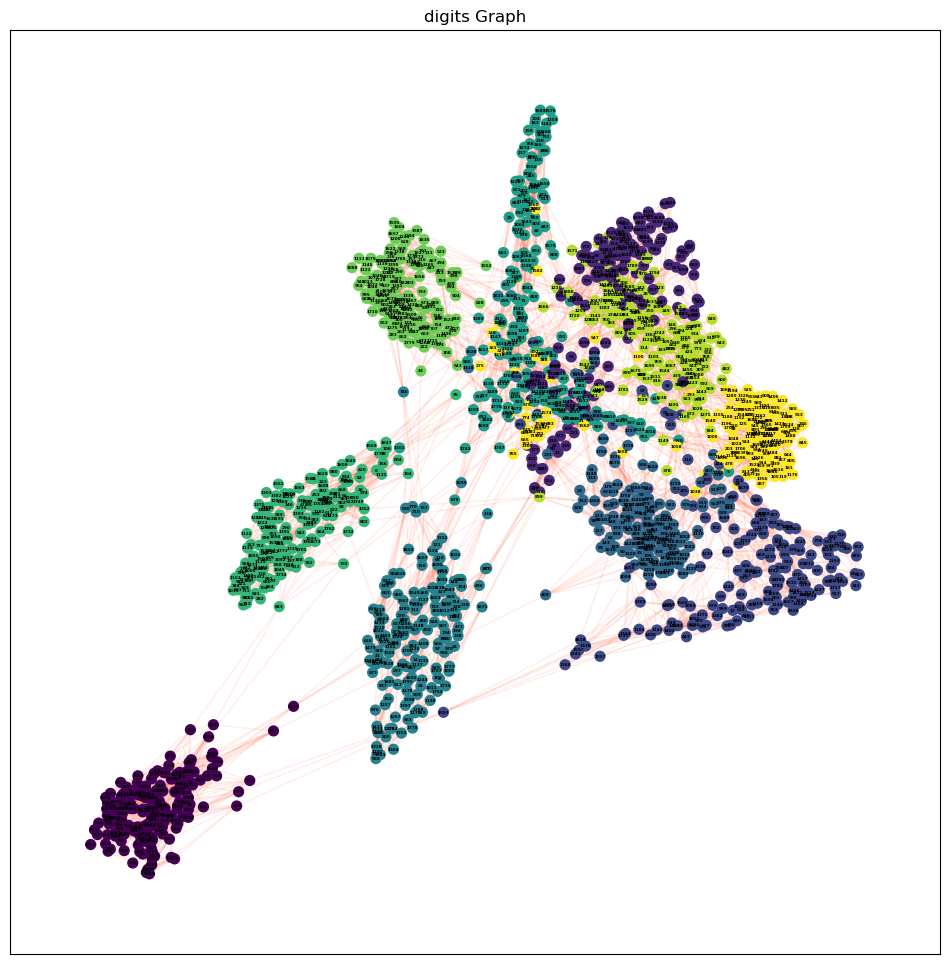

In [36]:
plt.figure( figsize=(12,12)) 
nx.draw_networkx_nodes(My_G, pos, node_color = node_colors, node_size = 50)

nx.draw_networkx_labels(My_G, pos,\
                        font_size = 3, font_weight = 'bold')
nx.draw_networkx_edges(My_G, pos, alpha = 0.1, edge_color = '#ff5733')
plt.title("digits Graph")
plt.show()

Just running $k$ nearest neighbours on a graph shows already some decent clustering. Even if we were not to know the labels, we certainly would be able to identify 7-8 distinct cluster.

<br>

## 5) The Leiden Graph

For running Leiden, we need a different graph object. Leiden does not run on ```networkx``` graphs.

In [38]:
G = ig.Graph(edges=edges, directed=False)

Finally, we run Leiden itself:

Finally, we now can run Leiden itself:

In [51]:
resolution_parameter = .3

In [52]:
partition = leidenalg.find_partition(G, leidenalg.RBConfigurationVertexPartition, resolution_parameter = resolution_parameter)
labels     = np.array(partition.membership)
print(f"Number of Leiden clusters: {len(np.unique(labels))}")

Number of Leiden clusters: 11


We just got 10 cluster, but that strongly depends on how detailed we distinguish between smaller structures within a cluster and regard these as separate cluster. Run Leiden for a different ```resolution_parameter``` in order to see how much the result can vary! 

Let us now compare the true lables to those that got assigned by Leiden. In order to generate a 2D plot in both cases we use UMAP.

In [47]:
newXYDigits = umap.UMAP().fit_transform(XSDigits)

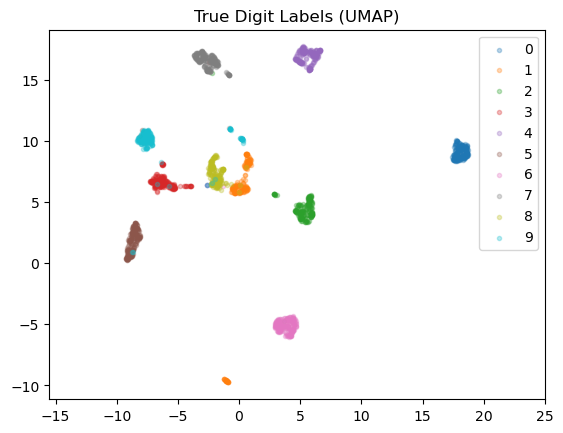

In [48]:
#true labels
for i in range(np.max(YDigits)+1):    

    idx = np.argwhere(YDigits == i)    
    plt.scatter(newXYDigits[idx, 0], newXYDigits[idx, 1], marker = '.',
    alpha = 0.3, label = str(i))
plt.gca().set_aspect('equal', 'datalim')
plt.title('True Digit Labels (UMAP)', fontsize = 12)
plt.legend()
plt.show()

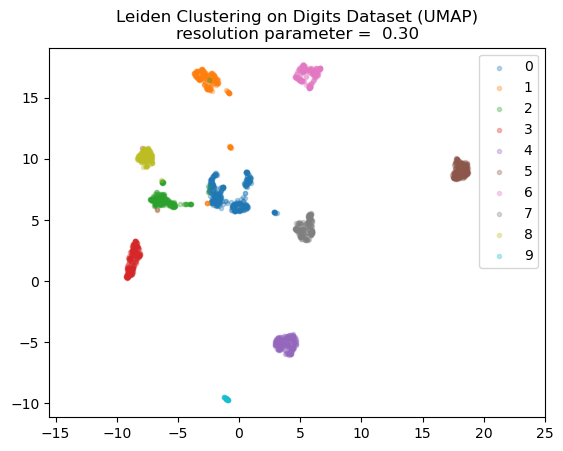

In [56]:
#Leiden labels
for i in range(np.max(labels)):    

    idx = np.argwhere(labels == i)    
    plt.scatter(newXYDigits[idx, 0], newXYDigits[idx, 1], marker = '.',
    alpha = 0.3, label = str(i))
plt.gca().set_aspect('equal', 'datalim')
plt.title(f"Leiden Clustering on Digits Dataset (UMAP)\nresolution parameter = {resolution_parameter: .2f}", fontsize = 12)
plt.legend()
plt.show()

The clustering is almost identical, but Leiden has a hard time to distinguish between the numbers 8 and 3!